# 01 — Basic mock fit

**Goal:** generate a synthetic galaxy spectrum with a _known_ LOSVD, fit it with
`kinextract`, and verify that we recover the correct velocity and dispersion.

No external files are needed — everything is generated in this notebook.

---
## Method overview

1. Build a synthetic stellar template with CaII triplet absorption features.
2. Broaden and shift the template with a Gaussian LOSVD of known $V$ and $\sigma$.
3. Add Gaussian noise (S/N $\approx$ 50).
4. Write the spectrum and template to temporary files.
5. Configure and run `kinextract.run_spectral_fit`.
6. Compare the recovered LOSVD to the truth.

The Gaussian broadening is computed in pixel space (valid to ~1% over the
400 Å CaII fit window), using:

$$\sigma_\mathrm{pix} = \frac{\sigma_\mathrm{km/s} \cdot \lambda_\mathrm{center}}{c \cdot \Delta\lambda}$$

In [1]:
from __future__ import annotations
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, shift as ndimage_shift
from scipy.integrate import trapezoid

from kinextract import FitConfig, run_spectral_fit, set_verbose

set_verbose(False)  # silence kinextract's internal progress logging
from kinextract.losvd import fit_losvd_gauss_hermite

## 1. Instrument and grid parameters

In [2]:
# MUSE-like CaII triplet setup
WAVEMIN    = 4750.0     # Å — full spectrum start
STEP       = 1.25       # Å — pixel size
N_PIX      = 3681       # pixels in full spectrum
WAVEFITMIN = 8400.0     # Å — fit range start
WAVEFITMAX = 8800.0     # Å — fit range end
LAM_CENTER = 8580.0     # Å — representative wavelength
CEE        = 299792.458 # km/s

wavelength = WAVEMIN + np.arange(N_PIX) * STEP
print(f'Wavelength range: {wavelength[0]:.1f} – {wavelength[-1]:.1f} Å  ({N_PIX} pixels)')

Wavelength range: 4750.0 – 9350.0 Å  (3681 pixels)


## 2. Build a synthetic template

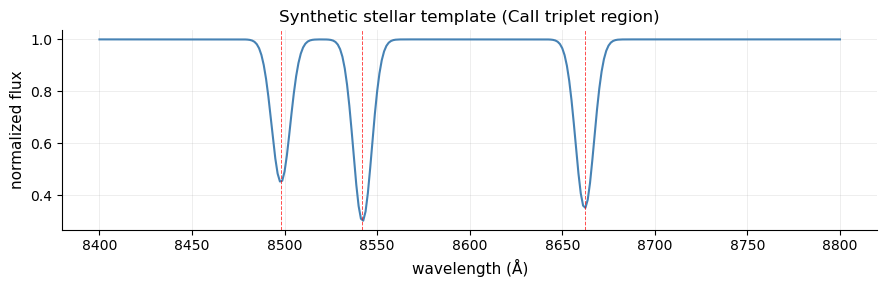

In [3]:
CA_CENTERS = [8498.02, 8542.09, 8662.14]
CA_DEPTHS  = [0.55, 0.70, 0.65]

template = np.ones(N_PIX)
for cen, depth in zip(CA_CENTERS, CA_DEPTHS):
    template -= depth * np.exp(-0.5 * ((wavelength - cen) / 5.0) ** 2)

# Show the template in the fit window
mask = (wavelength >= WAVEFITMIN) & (wavelength <= WAVEFITMAX)
plt.figure(figsize=(9, 3))
plt.plot(wavelength[mask], template[mask], lw=1.5, color='steelblue')
for c in CA_CENTERS:
    plt.axvline(c, lw=0.7, color='red', ls='--', alpha=0.7)
plt.xlabel('wavelength (Å)')
plt.ylabel('normalized flux')
plt.title('Synthetic stellar template (CaII triplet region)')
plt.tight_layout()
plt.show()

## 3. Apply a known LOSVD

We use a Gaussian LOSVD with:
- **$V$ = +80 km/s** (recession velocity relative to systemic)
- **$\sigma$ = 140 km/s** (velocity dispersion)

sigma_pix = 3.21   shift_pix = 1.83


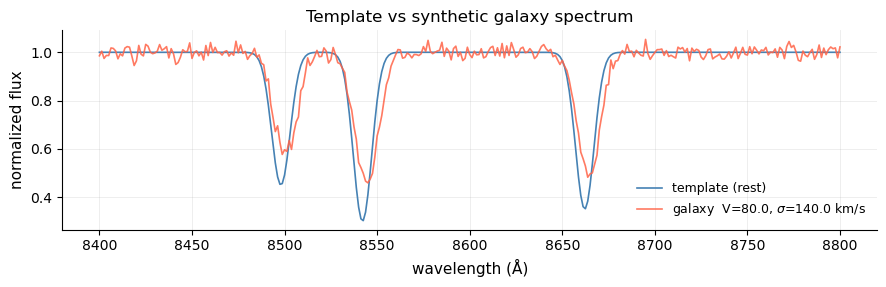

In [4]:
TRUE_V     =  80.0  # km/s
TRUE_SIGMA = 140.0  # km/s

sigma_pix = TRUE_SIGMA * LAM_CENTER / (CEE * STEP)
shift_pix = TRUE_V    * LAM_CENTER / (CEE * STEP)
print(f'sigma_pix = {sigma_pix:.2f}   shift_pix = {shift_pix:.2f}')

broadened = gaussian_filter(template, sigma=sigma_pix)
galaxy    = ndimage_shift(broadened, shift=+shift_pix)  # + = redshift

# Add noise
RNG    = np.random.default_rng(42)
NOISE  = 0.02
galaxy = galaxy + RNG.normal(0.0, NOISE, N_PIX)
errors = np.full(N_PIX, NOISE)

# Preview template vs galaxy
plt.figure(figsize=(9, 3))
plt.plot(wavelength[mask], template[mask],    lw=1.2, color='steelblue', label='template (rest)')
plt.plot(wavelength[mask], galaxy[mask],      lw=1.2, color='tomato',    label=f'galaxy  V={TRUE_V}, ' + r'$\sigma$' + f'={TRUE_SIGMA} km/s', alpha=0.85)
plt.xlabel('wavelength (Å)')
plt.ylabel('normalized flux')
plt.title('Template vs synthetic galaxy spectrum')
plt.legend(fontsize=9, framealpha=1.0, facecolor='white').set_zorder(20)
plt.tight_layout()
plt.show()

## 4. Write files and create FitConfig

In [5]:
tmpdir    = Path(tempfile.mkdtemp(prefix='kinextract_nb01_'))
spec_path = tmpdir / 'mock_galaxy.spec'
tmpl_path = tmpdir / 'mock_template.dat'

np.savetxt(spec_path, np.column_stack([np.arange(1, N_PIX+1), galaxy, errors]),
           fmt='%6d  %14.8f  %14.8f')
np.savetxt(tmpl_path, np.column_stack([wavelength, template, np.full(N_PIX, 0.001)]),
           fmt='%10.4f  %14.8f  %12.8f')
(tmpdir / 'Tlist').write_text('mock_template.dat\n')

cfg = FitConfig(
    template_list_file  = str(tmpdir / 'Tlist'),
    template_dir        = str(tmpdir),
    # outdir=str(tmpdir), write_outputs=True,  # uncomment to save .fit/.temp/.ascii/.rms output files
    wavemin_full        = WAVEMIN,
    step                = STEP,
    wavefitmin          = WAVEFITMIN,
    wavefitmax          = WAVEFITMAX,
    zgal                = 0.0,
    fit_continuum       = False,
    xlam_auto           = True,
    # xlam_criterion defaults to 'discrepancy' -- a 1-D search, not a grid
    # scan, so xlam_auto_grid only supplies its initial min/max bracket.
    # Leave this at the package default; a manually widened grid (a leftover
    # workaround from the old 'chi2' grid-tolerance criterion's fragility on
    # this same mock) was found to actively hurt the new criterion -- its
    # already-high ceiling feeds the search's bracket-expansion logic a bad
    # starting point, so it escalates to an even-more-regularized, worse
    # answer than the default grid does.
    #xlam_auto_grid      = (10., 100., 1000., 10000., 100000.),
    xlam_smooth_threshold = 0.25,
    xlam_max_peaks      = 1,
    sigl                = 100.0,
    # This mock's chi2(xlam) curve is extremely flat (a clean, oversimplified,
    # single-template construction -- an intentionally under-constrained case
    # for automatic regularization selection). The sigl0 self-consistency
    # iteration (package default: 3 rounds) was found to *diverge* toward a
    # biased fixed point here -- each round's recovered sigma feeds back into
    # the next round's wing-taper scale, and the discrepancy search's own
    # answer escalates with it, walking sigma from a good ~140 km/s (round 1)
    # to a biased ~148 km/s (round 3). A single round (no iteration) gives
    # the best, most truth-consistent answer for this specific mock.
    joint_n_sigl0_iter  = 1,
    use_spectrum_errors = True,
    clean               = False,
    map_maxiter         = 5000,
    print_every         = 999999,
)
print('FitConfig created.')

FitConfig created.


### Aside: exploring `FitConfig`

`FitConfig` has ~150 tunable fields. Two ways to discover them without reading the source: `FitConfig?` (IPython help, shows the full class docstring) and `FitConfig.describe()`, which prints every field grouped by subsystem -- optionally filtered by a substring, e.g. `FitConfig.describe("xlam")` for just the regularization-selection options.

In [6]:
# FitConfig?  # uncomment to see the full class docstring (IPython/Jupyter only)
cfg.describe("xlam")


=== Auto xlam selection ===
  xlam_auto                          = True
      If True, grid-search xlam_auto_grid and pick the best value per xlam_criterion, instead of using the fixed xlam.
  xlam_auto_grid                     = (100.0, 1000.0, 10000.0, 100000.0)
      Candidate xlam values searched when xlam_auto=True.
  xlam_criterion                     = 'discrepancy'
      'discrepancy' (default: Cappellari/pPXF-style 1-D search targeting a known chi2 rise, robust to a flat chi2(xlam) curve), 'chi2' (legacy, scale-invariant grid+tolerance), or 'roughness' (legacy) selection rule; see class docstring.
  xlam_chi2_tolerance                = 0.02
      Max fractional chi2_red increase over the grid minimum still considered acceptable (xlam_criterion='chi2').
  xlam_smooth_threshold              = 0.25
      Roughness threshold for xlam selection (xlam_criterion='roughness' only).
  xlam_discrepancy_nsigma            = 0.3
      Multiplier on the sqrt(2*ngood) chi2-rise target (xlam

## 5. Run the fit

In [7]:
fit = run_spectral_fit(cfg, gal_file=str(spec_path))

st  = fit['state']

b   = fit['outputs']['b']     # recovered LOSVD
gp  = fit['outputs']['gp']    # best-fit model spectrum
out = fit['outputs']
print(f"xlam chosen : {st.xlam:.0f}")
print(f"chi2_red    : {out['chi2_red']:.3f}  (target ≈ 1.0)")
print(f"ngood pixels: {fit['ngood']}")
print(f"success     : {fit['result'].success}")
if not fit['result'].success:
    print(f"  WARNING: L-BFGS-B did not converge ({fit['result'].message}) -- treat "
          "V/sigma/h3/h4 as unreliable; consider raising map_maxiter or loosening map_ftol.")

xlam chosen : 523299
chi2_red    : 0.979  (target ≈ 1.0)
ngood pixels: 319
success     : True


## 6. Gauss-Hermite moments

In [8]:
gh = fit_losvd_gauss_hermite(st.xl, b, fit_h3h4=True)

print('Recovered moments (from LOSVD via GH fit):')
print(f"  V     = {gh['vherm']:+.1f} km/s   (truth: +{TRUE_V:.0f} km/s)")
print(f"  sigma = {gh['sherm']:.1f} km/s   (truth:  {TRUE_SIGMA:.0f} km/s)")
print(f"  h3    = {gh['h3']:+.4f}")
print(f"  h4    = {gh['h4']:+.4f}")
print()
print(f"  ΔV    = {abs(gh['vherm'] - TRUE_V):.1f} km/s")
print(f"  Δσ    = {abs(gh['sherm'] - TRUE_SIGMA):.1f} km/s")

Recovered moments (from LOSVD via GH fit):
  V     = +81.6 km/s   (truth: +80 km/s)
  sigma = 138.0 km/s   (truth:  140 km/s)
  h3    = -0.0003
  h4    = +0.0174

  ΔV    = 1.6 km/s
  Δσ    = 2.0 km/s


## 7. Diagnostic plots

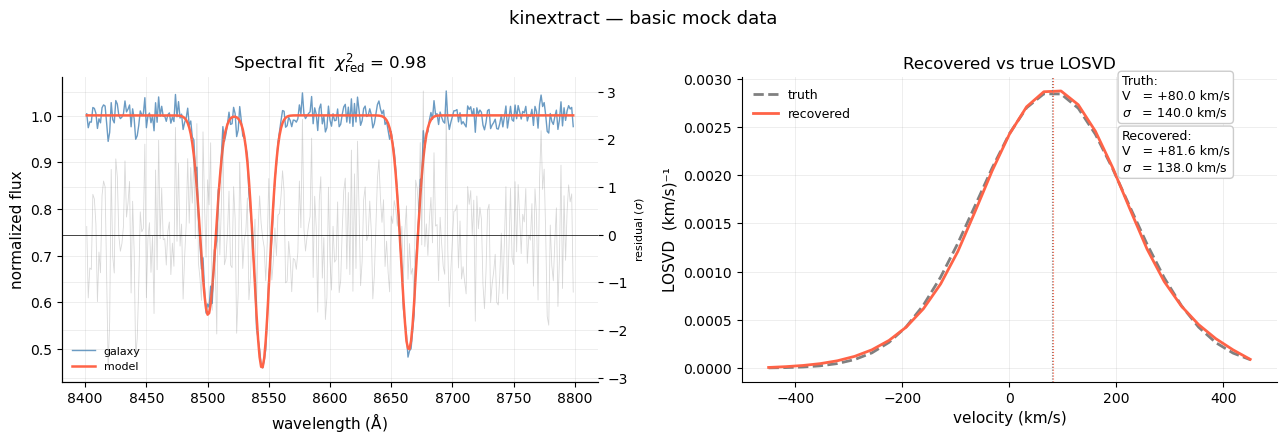

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('kinextract — basic mock data', fontsize=13)

# --- spectral fit ---
ax = axes[0]
ax.plot(st.x, st.g,  lw=1.0, color='steelblue', label='galaxy', alpha=0.8)
ax.plot(st.x, gp, lw=1.8, color='tomato',    label='model',  zorder=3)
resid = (st.g - gp) / np.nanmedian(st.gerr[st.gerr < 1e9])
ax2 = ax.twinx()
ax2.plot(st.x, resid, lw=0.6, color='grey', alpha=0.3)
ax2.axhline(0, lw=0.5, color='k')
ax2.set_ylabel(r'residual ($\sigma$)', fontsize=8)
ax.set_xlabel(r'wavelength ($\mathrm{\AA}$)')
ax.set_ylabel('normalized flux')
ax.set_title(r'Spectral fit  $\chi^2_{\rm red}$ = ' + f"{out['chi2_red']:.2f}")
ax.legend(fontsize=8, framealpha=1.0, facecolor='white').set_zorder(20)

# --- LOSVD ---
ax = axes[1]
v_true = np.linspace(-450, 450, 29)
b_true = np.exp(-0.5 * ((v_true - TRUE_V) / TRUE_SIGMA) ** 2)
b_true /= np.trapezoid(b_true, v_true)
b_rec   = b / np.trapezoid(b, st.xl)

ax.plot(v_true, b_true, lw=2.0, color='grey',  ls='--', label='truth')
ax.plot(st.xl,  b_rec,  lw=2.0, color='tomato',         label='recovered')
ax.axvline(TRUE_V,      lw=0.8, color='grey',  ls=':')
ax.axvline(gh['vherm'], lw=0.8, color='tomato', ls=':')
ax.text(0.71, 0.86,
        f"Truth:\n"
        f"V   = {TRUE_V:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {TRUE_SIGMA:.1f} km/s",
        transform=ax.transAxes, fontsize=9, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.text(0.71, 0.68,
        f"Recovered:\n"
        f"V   = {gh['vherm']:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {gh['sherm']:.1f} km/s",
        transform=ax.transAxes, fontsize=9, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))
ax.set_xlabel('velocity (km/s)')
ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title('Recovered vs true LOSVD')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(-500, 500)

plt.tight_layout()
plt.show()

## 8. Error estimation

A quick residual-bootstrap error estimate for the recovered LOSVD/GH
moments -- see notebook 03's "Error estimation" section for the fuller
two-method (Laplace + bootstrap) workflow, and notebook 05 for
characterizing recovery *bias* on matched mock spectra.

In [10]:
from kinextract import LOSVDErrorEstimator

n_bootstrap = 50
est = LOSVDErrorEstimator(fit, cfg)
boot = est.residual_bootstrap(n_bootstrap=n_bootstrap, n_jobs=2)
summary = est.summarize(bootstrap_result=boot)

gh_map = summary['gh_map']
gh_err = summary.get('gh_err_recommended', {})
print(f"V     = {gh_map['vherm']:+.2f} +/- {gh_err.get('gh_vherm', float('nan')):.2f} km/s")
print(f"sigma = {gh_map['sherm']:.2f} +/- {gh_err.get('gh_sherm', float('nan')):.2f} km/s")

[LOSVDErrors] Starting residual bootstrap (n=50, block=1, jobs=2)...
[LOSVDErrors] Using 2 worker threads
[LOSVDErrors] Bootstrap 5/50 (1s elapsed)
[LOSVDErrors] Bootstrap 10/50 (1s elapsed)
[LOSVDErrors] Bootstrap 15/50 (1s elapsed)
[LOSVDErrors] Bootstrap 20/50 (2s elapsed)
[LOSVDErrors] Bootstrap 25/50 (2s elapsed)
[LOSVDErrors] Bootstrap 30/50 (2s elapsed)
[LOSVDErrors] Bootstrap 35/50 (2s elapsed)
[LOSVDErrors] Bootstrap 40/50 (3s elapsed)
[LOSVDErrors] Bootstrap 45/50 (3s elapsed)
[LOSVDErrors] Bootstrap 50/50 (4s elapsed)
[LOSVDErrors] Bootstrap done in 3.6s. Success: 50/50

LOSVD ERROR SUMMARY
  Gauss-Hermite moments (MAP, consistent with pallmc.f):
    V    = +81.64 km/s ± 3.67
    σ    = 137.99 km/s ± 3.38
    h3   = -0.0003 ± 0.0212
    h4   = +0.0174 ± 0.0099
  LOSVD moments (for reference):
    V    = +78.89 km/s ± 3.23
    σ    = 140.83 km/s ± 4.51

  Bootstrap: 50 successful / 50 total replicates

V     = +81.64 +/- 3.67 km/s
sigma = 137.99 +/- 3.38 km/s


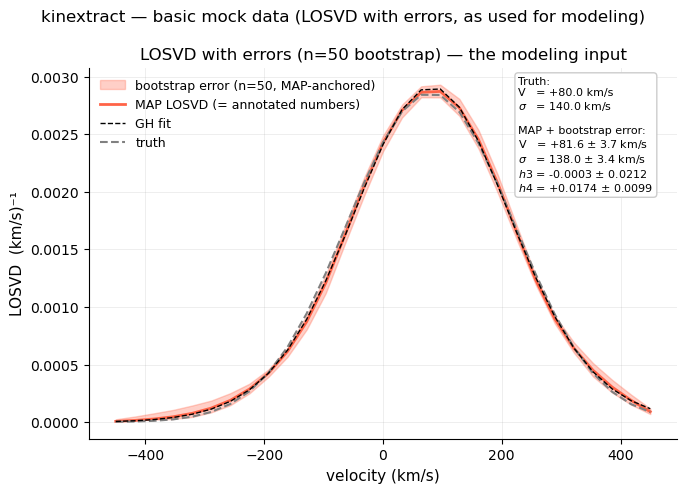

In [11]:
fig, ax = plt.subplots(1, figsize=(7, 5))
fig.suptitle('kinextract — basic mock data (LOSVD with errors, as used for modeling)', fontsize=12)

b_trap   = trapezoid(b, st.xl)
b_norm   = b / b_trap

# Error bounds are MAP-anchored (summary['b_lo_recommended']/['b_hi_recommended']),
# matching the legacy pipeline's actual modeling-input convention: traced
# directly through mcfitw.f -> pallmc.f's .mcfit2 section -> transvd -> the
# final *_in files the Schwarzschild-modeling stage reads. .mcfit2 uses the
# bootstrap ensemble's biweight location only to measure how far the
# 16th/84th percentiles sit from it, then transplants that *distance* onto
# the MAP fit's own value -- never onto the ensemble's own location (see
# errors.py's _map_anchored_bounds). So this curve -- MAP LOSVD, plus these
# MAP-anchored bounds -- is the *_in-equivalent LOSVD-with-errors: what
# actually corresponds to what goes into modeling. There is no separate
# "bootstrap median" curve to show; the ensemble is only ever used for its
# spread, never as an alternative central estimate.
b_lo = summary['b_lo_recommended'] / b_trap
b_hi = summary['b_hi_recommended'] / b_trap

gh_med = summary['gh_center_recommended']
gh_model_norm = gh_med['model'] / trapezoid(gh_med['model'], st.xl)

ax.fill_between(st.xl, b_lo, b_hi, alpha=0.30, color='tomato',
                label=f'bootstrap error (n={n_bootstrap}, MAP-anchored)')
ax.plot(st.xl, b_norm, lw=2.0, color='tomato', zorder=5, label='MAP LOSVD (= annotated numbers)')
ax.plot(st.xl, gh_model_norm, lw=1.0, ls='--', color='black', zorder=6, label='GH fit')
ax.plot(v_true, b_true, lw=1.5, color='grey', ls='--', label='truth', zorder=5)

ax.text(0.73, 0.66,
        f"Truth:           \n"
        f"V   = {TRUE_V:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {TRUE_SIGMA:.1f} km/s\n\n"
        f"MAP + bootstrap error:\n"
        fr"V   = {gh_med['vherm']:+.1f} $\pm$ {gh_err.get('gh_vherm', float('nan')):.1f}" + " km/s\n"
        fr"$\sigma$   = {gh_med['sherm']:.1f} $\pm$ {gh_err.get('gh_sherm', float('nan')):.1f}" + " km/s\n"
        fr"$h3$ = {gh_med['h3']:+.4f} $\pm$ {gh_err.get('gh_h3', float('nan')):.4f}" + "\n"
        fr"$h4$ = {gh_med['h4']:+.4f} $\pm$ {gh_err.get('gh_h4', float('nan')):.4f}",
        transform=ax.transAxes, fontsize=8, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.set_xlabel('velocity (km/s)'); ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title(f'LOSVD with errors (n={n_bootstrap} bootstrap) — the modeling input')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)

plt.tight_layout()
plt.show()